In [16]:
# === Libraries ===
import shap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.base import clone
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# Plotting style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [17]:
df = pd.read_csv("FMCG_2022_2024.csv", parse_dates=["date"])
df_eda = df.copy()

In [18]:
# df = df.rename(columns = {'Unique_ID' : 'sku'}) 

In [19]:
print("Shape:", df_eda.shape)

Shape: (190757, 14)


In [20]:
print("Duplicated rows:", df_eda.duplicated().sum())

Duplicated rows: 0


In [21]:
# Remove rows with any negative values in those columns
df = df[(df[["units_sold", "stock_available", "delivered_qty", "delivery_days"]] >= 0).all(axis=1)].copy()
df = df.sort_values(["sku", "date"]).reset_index(drop=True)
initial_rows = df_eda.shape[0]
final_rows = df.shape[0]
print(f"Rows removed due to negative values: {initial_rows - final_rows}")

Rows removed due to negative values: 3


In [22]:
# Lag features for target
for lag in [1, 2, 3, 7, 14, 28]:
    df[f"lag_{lag}"] = df.groupby("sku")["units_sold"].shift(lag)

# Momentum (ratios of lags)
df["momentum_7_1"] = df["lag_1"] / (df["lag_7"] + 1e-3)
df["momentum_14_7"] = df["lag_7"] / (df["lag_14"] + 1e-3)

# Rolling statistics
df["rolling_mean_7"] = df.groupby("sku")["units_sold"].transform(lambda x: x.shift(1).rolling(7).mean())
df["rolling_std_7"]  = df.groupby("sku")["units_sold"].transform(lambda x: x.shift(1).rolling(7).std())
df["rolling_max_7"]  = df.groupby("sku")["units_sold"].transform(lambda x: x.shift(1).rolling(7).max())
df["rolling_min_7"]  = df.groupby("sku")["units_sold"].transform(lambda x: x.shift(1).rolling(7).min())

In [23]:
# Rolling trend (linear regression slope over last 7 days)
def rolling_trend(x):
    return x.shift(1).rolling(7).apply(lambda z: np.polyfit(range(len(z)), z, 1)[0] if len(z.dropna()) == 7 else np.nan)

df["trend_7"] = df.groupby("sku")["units_sold"].transform(rolling_trend)

# Lags for price, promo, delivery, stock
df["price_lag_1"] = df.groupby("sku")["price_unit"].shift(1)
df["promo_lag_1"] = df.groupby("sku")["promotion_flag"].shift(1)
df["promo_effect"] = df["promotion_flag"] * df["lag_1"]
df["delivery_lag_7"] = df.groupby("sku")["delivery_days"].shift(7)
df["stock_lag_1"] = df.groupby("sku")["stock_available"].shift(1)

In [24]:
# SKU global statistics
sku_stats = df.groupby("sku")["units_sold"].agg(["mean", "min", "max", "std"]).reset_index()
sku_stats.columns = ["sku", "sku_mean", "sku_min", "sku_max", "sku_std"]
df = df.merge(sku_stats, on="sku", how="left")

# Date features
df["is_month_start"] = df["date"].dt.is_month_start.astype(int)
df["is_month_end"]   = df["date"].dt.is_month_end.astype(int)
df["dayofweek"]      = df["date"].dt.dayofweek
df["month"]          = df["date"].dt.month
df["year"]           = df["date"].dt.year
df["is_weekend"]     = df["dayofweek"].isin([5, 6]).astype(int)

In [25]:
# Rolling stats per category
df["category_rolling_mean_7"] = df.groupby("category")["units_sold"].transform(lambda x: x.shift(1).rolling(7).mean())
df["category_rolling_std_7"]  = df.groupby("category")["units_sold"].transform(lambda x: x.shift(1).rolling(7).std())

# Price & promo rolling
df["price_rolling_mean_7"] = df.groupby("sku")["price_unit"].transform(lambda x: x.shift(1).rolling(7).mean())
df["promo_rolling_7"]      = df.groupby("sku")["promotion_flag"].transform(lambda x: x.shift(1).rolling(7).sum())

# Calendar position
df["day"] = df["date"].dt.day
df["week_of_month"] = df["day"] // 7 + 1

In [26]:
# Stockout indicators
df["stockout_flag"] = ((df["stock_available"] == 0) & (df["delivered_qty"] > 0)).astype(int)
df["rolling_stockouts_7"] = df.groupby("sku")["stockout_flag"].transform(lambda x: x.shift(1).rolling(7).sum())

# Time since last promo / delivery
def time_since_event(series):
    return series[::-1].cumsum()[::-1] * series

df["time_since_promo"] = df.groupby("sku")["promotion_flag"].transform(lambda x: time_since_event(x == 0))
df["time_since_delivery"] = df.groupby("sku")["delivery_days"].transform(lambda x: time_since_event(x == 0))

# Seasonal signals
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
df["dow_sin"]   = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"]   = np.cos(2 * np.pi * df["dayofweek"] / 7)

# Interaction features
df["promo_dow"] = df["promotion_flag"] * df["dayofweek"]
df["price_x_stock"] = df["price_unit"] * df["stock_available"]

In [27]:
# Ordinal encoding
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df[["sku_cat", "segment_cat", "category_cat"]] = enc.fit_transform(df[["sku", "segment", "category"]])

# Remove rows with NaN after feature generation
df = df.dropna()

# Feature set
exclude_cols = ["date", "sku", "brand", "segment", "channel", "region", "pack_type", "delivered_qty", "units_sold", "category"]
features = [col for col in df.columns if col not in exclude_cols and not np.issubdtype(df[col].dtype, np.datetime64)]

categorical_features = [
    "sku_cat", "segment_cat", "category_cat",
    "dayofweek", "month", "is_weekend",
    "promotion_flag", "is_month_start", "is_month_end"
]
target = "units_sold"

In [28]:
# Split data based on time
cutoff_date = df["date"].max() - pd.Timedelta(days=42)
train = df[df["date"] <= cutoff_date].copy()
test  = df[df["date"] > cutoff_date].copy()

In [29]:
category_models = {}
category_preds = []
category_metrics = {}

def safe_mape(y_true, y_pred):
    mask = y_true != 0
    return mean_absolute_percentage_error(y_true[mask], y_pred[mask])

for cat in tqdm(df["category"].unique(), desc="Training per category"):
    df_cat = df[df["category"] == cat].copy()
    cutoff = df_cat["date"].max() - pd.Timedelta(days=42)
    train_c = df_cat[df_cat["date"] <= cutoff]
    test_c  = df_cat[df_cat["date"] > cutoff]

    if len(train_c) < 30 or len(test_c) < 7:
        continue

    # Initial model for feature ranking
    base_model = LGBMRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42, verbose=-1)
    base_model.fit(train_c[features], train_c[target])
    fi = pd.Series(base_model.feature_importances_, index=features).sort_values(ascending=False)

    best_score = float("inf")
    best_features = features

    # Feature selection loop
    for k in range(10, len(features) + 1, 5):
        top_k = fi.head(k).index.tolist()
        model_k = clone(base_model).fit(train_c[top_k], train_c[target])
        preds_k = np.clip(model_k.predict(test_c[top_k]), 0, None)
        rmse_k = np.sqrt(mean_squared_error(test_c[target], preds_k))
        if rmse_k < best_score:
            best_score = rmse_k
            best_features = top_k

    # Final model on selected features
    model = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=7,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1 
    )
    model.fit(
        train_c[best_features], train_c[target],
        categorical_feature=[f for f in categorical_features if f in best_features]
    )

    test_c = test_c.copy()
    test_c["prediction"] = np.clip(model.predict(test_c[best_features]), 0, None)
    category_preds.append(test_c)

    category_models[cat] = {"model": model, "features": best_features}

    # Metrics
    rmse = np.sqrt(mean_squared_error(test_c[target], test_c["prediction"]))
    mape = safe_mape(test_c[target], test_c["prediction"])
    smape = np.mean(2 * np.abs(test_c[target] - test_c["prediction"]) /
                    (np.abs(test_c[target]) + np.abs(test_c["prediction"]) + 1e-8))
    r2 = r2_score(test_c[target], test_c["prediction"])

    category_metrics[cat] = {
        "RMSE": rmse,
        "MAPE": mape,
        "SMAPE": smape,
        "R2": r2,
        "N_features": len(best_features)
    }

Training per category: 100%|█████████████████████████████████████████████████████████████| 5/5 [00:50<00:00, 10.11s/it]


In [30]:
# === Aggregate all predictions ===
df_all = pd.concat(category_preds, axis=0)

# === Metrics per category ===
metrics_by_category = pd.DataFrame(category_metrics).T.reset_index().rename(columns={"index": "category"})
metrics_by_category = metrics_by_category[["category", "R2", "SMAPE", "MAPE", "N_features"]]
metrics_by_category = metrics_by_category.sort_values("MAPE")  # ← sort by MAPE (ascending)
metrics_by_category

,category,R2,SMAPE,MAPE,N_features
2,ReadyMeal,0.792463,0.209947,0.190381,25.0
3,SnackBar,0.779225,0.195098,0.200788,30.0
4,Yogurt,0.768993,0.204811,0.209776,35.0
0,Juice,0.645478,0.200753,0.220604,25.0
1,Milk,0.757663,0.205067,0.222767,10.0


In [31]:
# === Metrics per SKU ===
def compute_metrics(group):
    y_true = group[target]
    y_pred = group["prediction"]
    mask = y_true != 0
    return pd.Series({
        "R2": r2_score(y_true, y_pred),
        "SMAPE": np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)),
        "MAPE": mean_absolute_percentage_error(y_true[mask], y_pred[mask]),
    })

metrics_by_sku = df_all.groupby("sku").apply(compute_metrics).reset_index()
print("\nBest SKUs by MAPE:")
metrics_by_sku.sort_values("MAPE", ascending=True).head(10).round(3)


Best SKUs by MAPE:


,sku,R2,SMAPE,MAPE
17,SN-028,0.786,0.164,0.173
11,RE-017,0.788,0.168,0.177
13,SN-010,0.785,0.184,0.180
12,RE-025,0.763,0.204,0.180
21,YO-005,0.763,0.188,0.192
25,YO-016,0.820,0.188,0.193
18,SN-030,0.748,0.213,0.193
9,RE-007,0.833,0.212,0.196
2,MI-006,0.812,0.174,0.197
10,RE-015,0.777,0.233,0.198


In [32]:
print("\n Worst SKUs by MAPE:")
metrics_by_sku.sort_values("MAPE", ascending=False).head(10).round(3)


 Worst SKUs by MAPE:


,sku,R2,SMAPE,MAPE
3,MI-008,0.610,0.223,0.271
4,MI-011,0.717,0.215,0.254
14,SN-013,0.726,0.196,0.236
24,YO-014,0.736,0.204,0.234
5,MI-022,0.755,0.191,0.227
16,SN-027,0.746,0.197,0.224
19,YO-001,0.745,0.199,0.224
0,JU-021,0.645,0.201,0.221
20,YO-003,0.725,0.212,0.215
1,MI-002,0.713,0.218,0.213


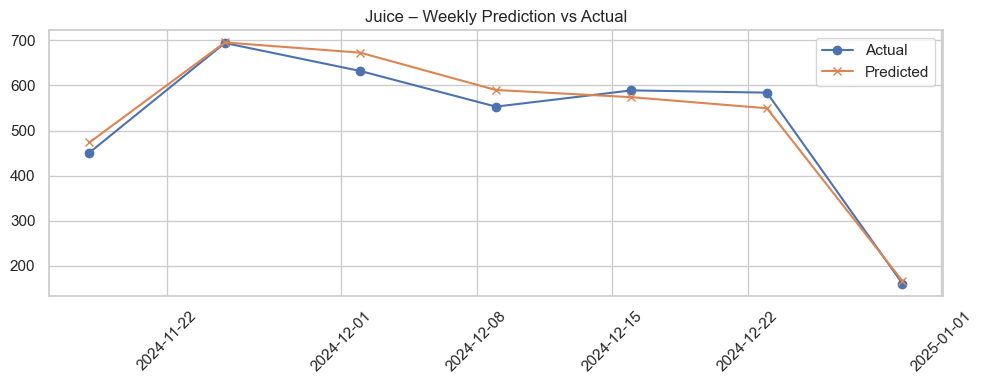

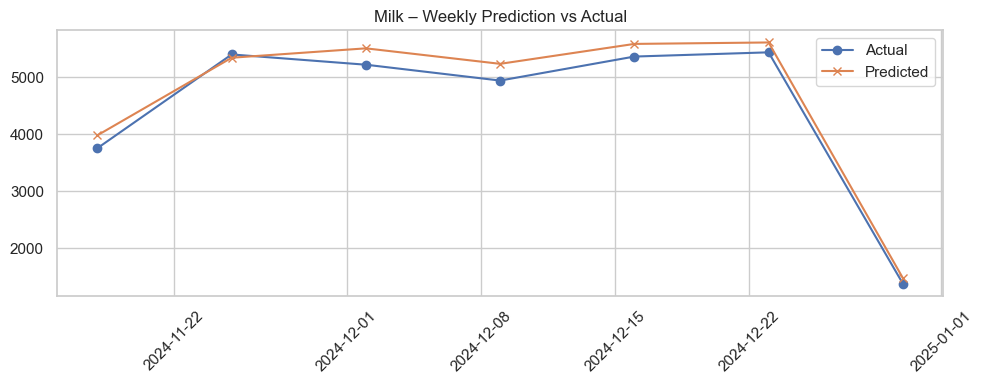

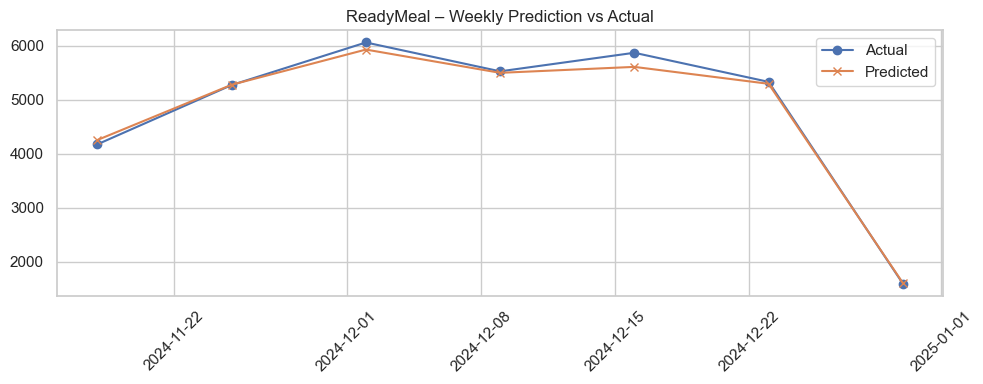

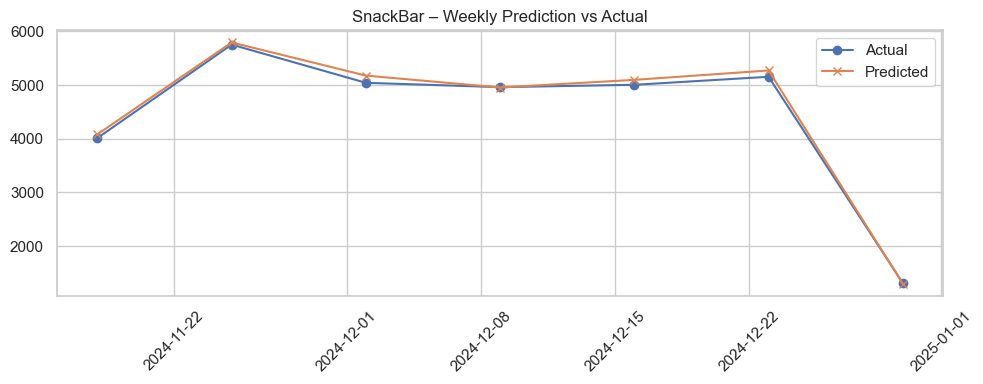

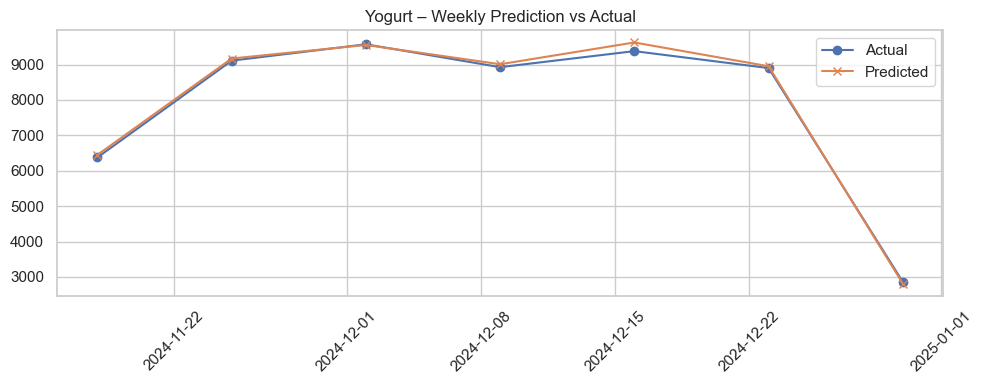

In [33]:
df_all["week"] = df_all["date"] - pd.to_timedelta(df_all["date"].dt.dayofweek, unit="d")
agg = df_all.groupby(["category", "week"])[["units_sold", "prediction"]].sum().reset_index()

for cat in agg["category"].unique():
    df_cat = agg[agg["category"] == cat]
    plt.figure(figsize=(10, 4))
    plt.plot(df_cat["week"], df_cat["units_sold"], label="Actual", marker="o")
    plt.plot(df_cat["week"], df_cat["prediction"], label="Predicted", marker="x")
    plt.title(f"{cat} – Weekly Prediction vs Actual")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()